In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import ClusterCentroids
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC


In [2]:
# 1. Perform additional cleaning beyond what you did in Assignment 6. Specify the improvements you made.
credit_df=pd.read_csv('Credit_card.csv')
credit_df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [3]:
credit_df = credit_df.drop(columns=['Ind_ID','Mobile_phone','Work_Phone','Phone','EMAIL_ID'])

In [4]:
# Convert categorical variables to numeric
credit_df = pd.get_dummies(credit_df, columns=['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income','EDUCATION', 'Marital_status','Housing_type','Type_Occupation'], drop_first=True)
credit_df.head()

,CHILDREN,Annual_income,Birthday_count,Employed_days,Family_Members,GENDER_M,Car_Owner_Y,Propert_Owner_Y,Type_Income_Pensioner,Type_Income_State servant,...,Type_Occupation_Laborers,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Waiters/barmen staff
0,0,180000.0,-18772.0,365243,2,True,True,True,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,315000.0,-13557.0,-586,2,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,315000.0,NaN,-586,2,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,NaN,-13557.0,-586,2,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,315000.0,-13557.0,-586,2,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
# replace NAN with the median
credit_df['Birthday_count']=credit_df['Birthday_count'].fillna(credit_df['Birthday_count'].median())
credit_df['Annual_income']=credit_df['Annual_income'].fillna(credit_df['Annual_income'].median())
credit_df['CHILDREN']=credit_df['CHILDREN'].fillna(credit_df['CHILDREN'].median())

In [6]:
X = credit_df.drop('Propert_Owner_Y', axis=1)
y = credit_df['Propert_Owner_Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)
regression = LogisticRegression(random_state=42, max_iter=10000).fit(X_train, y_train)
y_predicted = regression.predict(X_test)
regression.score(X_test, y_test)


0.6903225806451613

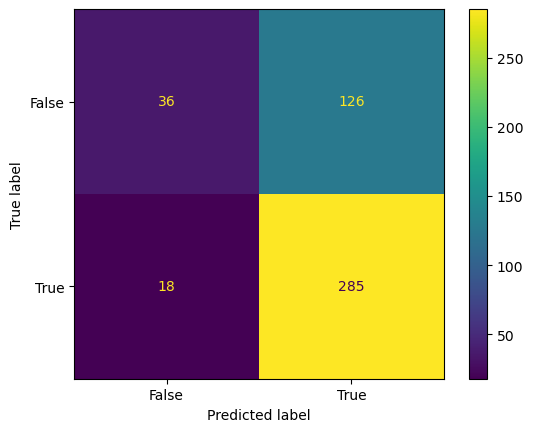

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted)

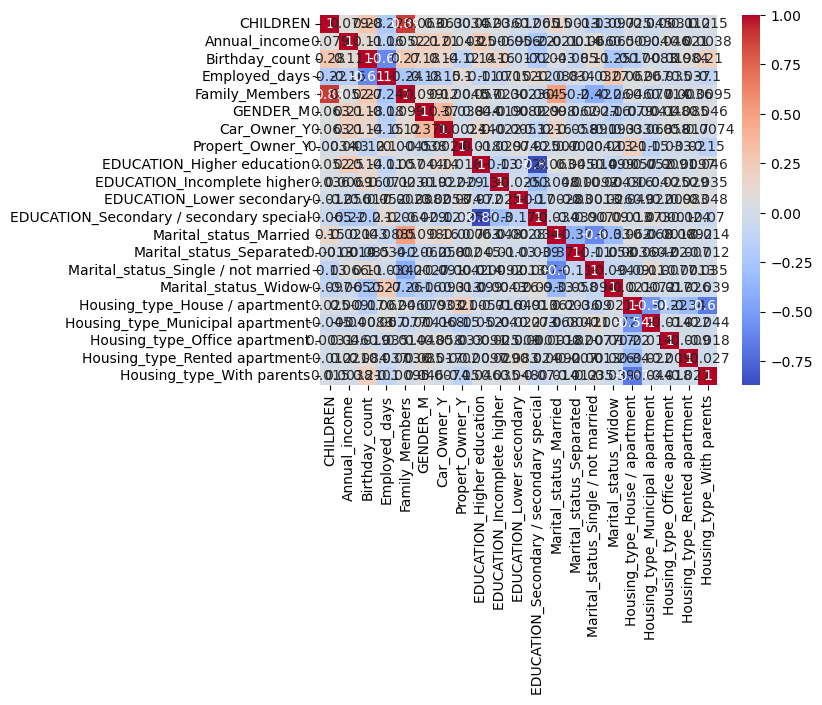

In [8]:
# every thing from here onward will be new data cleaning
# want to drop redundant or uncorrelated columns
credit_df = credit_df.drop(columns=[col for col in credit_df.columns if col.startswith('Type_Income_')])
credit_df = credit_df.drop(columns=[col for col in credit_df.columns if col.startswith('Type_Occupation_')])
sns.heatmap(credit_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
X = credit_df.drop('Propert_Owner_Y', axis=1)
y = credit_df['Propert_Owner_Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
#Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
regression = LogisticRegression(random_state=42, max_iter=10000).fit(X_train, y_train)
y_predicted = regression.predict(X_test)
regression.score(X_test, y_test)


0.6935483870967742

In [10]:
# 2.Perform combined, oversampling, or undersampling on the dataset you selected for Assignment 6.  Explain why you chose what you did. How did this impact the results of your KNN and Logistic Regression? 
credit_df['Propert_Owner_Y'].value_counts()


Propert_Owner_Y
True     1010
False     538
Name: count, dtype: int64

0.5655913978494623


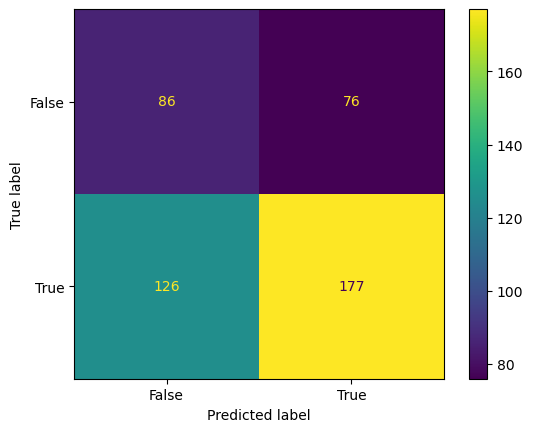

In [11]:
# knn
X = credit_df.drop('Propert_Owner_Y', axis=1)
y = credit_df['Propert_Owner_Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)


ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)


knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_resampled, y_resampled)

y_pred = knn.predict(X_test)

print(knn.score(X_test, y_test))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5763440860215053

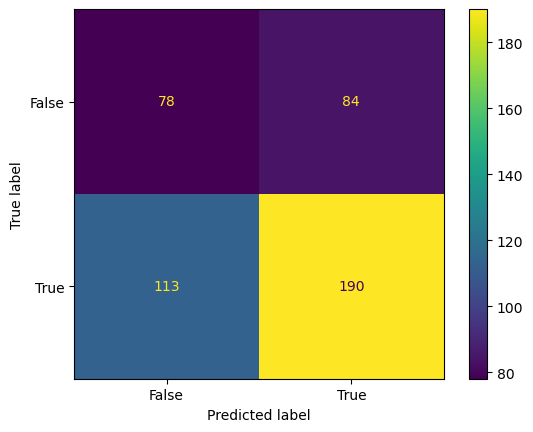

In [12]:
#logistic regression
X = credit_df.drop('Propert_Owner_Y', axis=1)
y = credit_df['Propert_Owner_Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)
ros = RandomOverSampler(random_state=42)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
model = LogisticRegression(random_state=42)
model.fit(X_resampled, y_resampled)

y_pred1 = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred1)
model.score(X_test, y_test)

In [13]:
# for both the knn and logistic regression, I chose to do oversampling to balance the 
# dataset by creating more of the minority class and because it yielded better accuracy than undersampling.
# However, since the dataset in not very unbalanced it was unnecessary to over or under sample and the accuracy actually went down for 
# both KNN and logistic regression.


In [14]:
# 3. Create an ROC Curve for the model and calculate the AUC 
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred1)
print(auc)

0.5542720938760544


Text(0, 0.5, 'True Positive Rate')

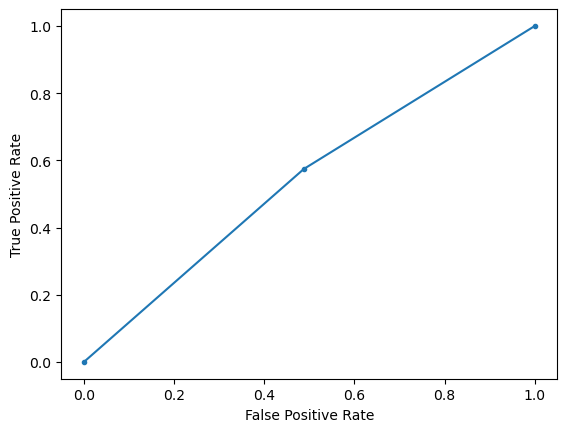

In [15]:
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

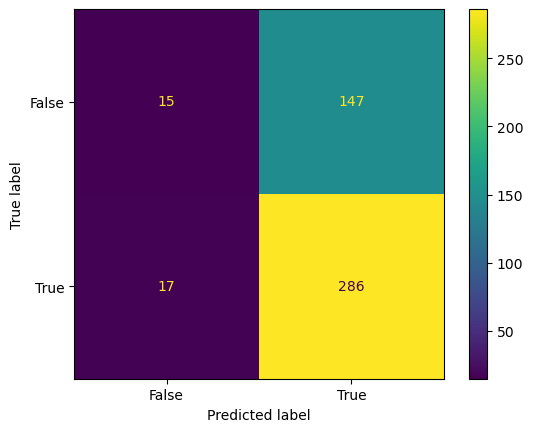

In [16]:
#4. Perform a linear SVM to predict the result from your dataset.
X = credit_df.drop('Propert_Owner_Y', axis=1)
y = credit_df['Propert_Owner_Y']

classifier = SVC(kernel='linear', random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42,
                                                    stratify=y)


classifier.fit(X_train, y_train)
classifier.score(X_test, y_test)
y_pred2 = classifier.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)

In [17]:
# recall
286/(286+17)

0.9438943894389439

In [18]:
# accuracy = tp+tn/total
(286+15)/(286+17+15+147)

0.6473118279569893

In [20]:
# the model led to a very good recall and also a better than when we over and undersampled accuracy score

In [19]:
# 5. What is outlier detection? Why is it important? What methods can you use for outlier detection?
# Outlier detection is the process of indentifying and dealing with high and low outliers in the data.
# there are a couple ways we can go about this, the most effective probably being to standardize our data.
# we can also us boxplots or data summaries to identify them and then we can decide if we want to delete them, replace them with the central tendency, or keep them